same as notebook 2 but try different dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

import torch
import torch.nn as nn

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
from torchvision.datasets import CIFAR10
from torchvision import transforms

tfm = transforms.ToTensor()  # -> float in [0,1], shape (C,H,W)
cifar_train = CIFAR10(root="./data", train=True, download=True, transform=tfm) # cifar_train.data.shape # 
cifar_test = CIFAR10(root="./data", train=False, download=True, transform=tfm)

In [4]:
len(cifar_test.targets)

10000

In [5]:
X_train = cifar_train.data # (50000, 32, 32, 3)
X_train = (X_train - X_train.min()) / X_train.max()

X_test = cifar_test.data # (10000, 32, 32, 3)
X_test = (X_test - X_test.min()) / X_test.max()

y_train = cifar_train.targets
y_test = cifar_test.targets

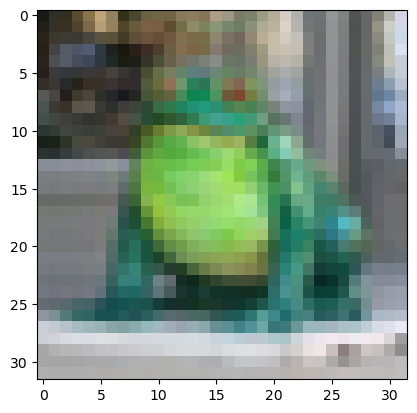

In [6]:
plt.imshow(X_train[19])

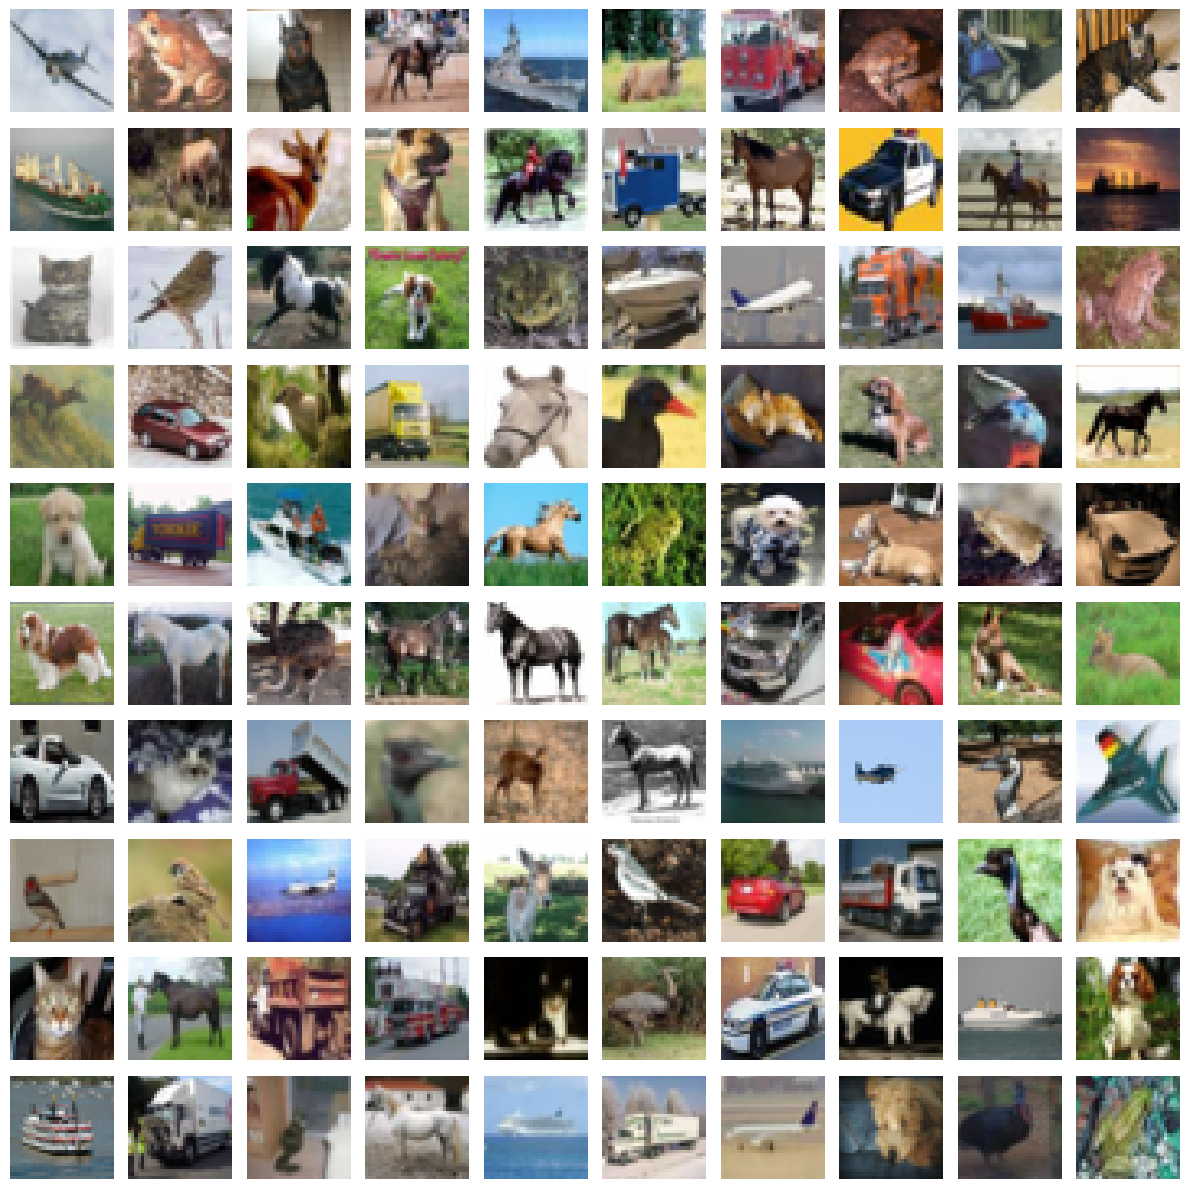

In [8]:
random_indices = np.random.choice(len(X_train), 100, replace=False)
fig, axes = plt.subplots(10, 10, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    # Reshape the flattened 1D array to 28x28 and plot it
    ax.imshow(X_train[random_indices[i]])
    ax.axis('off') # Hide axes for a cleaner look
plt.tight_layout()
plt.show()

# Prepare Datasets

In [14]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CIFAR10Dataset(Dataset):
    """ Takes Tensor of data between [0, 1] and transfer it to [-1, 1] by using Norrmalize"""
    def __init__(self, numpy_arr):
        self.data = torch.tensor(numpy_arr)
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        x = self.data[idx].float()
        return x

# Compare Simple PCA with AE

In [15]:
import torch.nn as nn

class SimpleLinearAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.encoder = nn.Linear(input_dim, latent_dim)
        self.decoder = nn.Linear(latent_dim, input_dim)
    
    def forward(self, x):
        return self.decoder(self.encoder(x))
    
class SimpleNonLinearAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, activation: nn.Module | None = None) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, latent_dim),
            activation if activation is not None else nn.ReLU(),
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, input_dim),
            nn.Sigmoid(),  #!! pixels should be in [0,1]
        )
    
    def forward(self, x):
        return self.decoder(self.encoder(x))
    
class StackedAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, hidden_dim: int = 100) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SELU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.SELU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.SELU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),  #!! pixels should be in [0,1]
        )
    
    def forward(self, x):
        return self.decoder(self.encoder(x))

In [18]:
def eval_ae_mse(model, dl):
    model.eval()
    total, n = 0.0, 0
    crit = nn.MSELoss()
    with torch.no_grad():
        for x in dl:
            x = x.to(device).view(x.size(0), -1)
            recon = model(x)
            loss = crit(recon, x)
            total += loss.item() * x.size(0)
            n += x.size(0)
    return total / n

def train_ae_mse(model, train_dl, test_dl, epochs, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()       
    for ep in range(1, epochs + 1):
        model.train()
        for x in train_dl:
            x = x.to(device).view(x.size(0), -1)
            recon = model(x)
            loss = crit(recon, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        latests_loss = eval_ae_mse(model, test_dl)
        print(f"epoch {ep:02d} | AE test MSE: {latests_loss:.6f}")
    return latests_loss
    

In [ ]:
latent_dim = 32
input_dim = X_train[0].shape[0] * X_train[0].shape[1] * X_train[0].shape[2]


train_ds = CIFAR10Dataset(X_train)
test_ds  = CIFAR10Dataset(X_test)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False)

 
linear_ae = SimpleLinearAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
train_ae_mse(linear_ae, train_dl, test_dl, epochs=30, lr=1e-3)

epoch 01 | AE test MSE: 0.042076
epoch 02 | AE test MSE: 0.030533
epoch 03 | AE test MSE: 0.025068
epoch 04 | AE test MSE: 0.022033
epoch 05 | AE test MSE: 0.020000
epoch 06 | AE test MSE: 0.018103
epoch 07 | AE test MSE: 0.016452
epoch 08 | AE test MSE: 0.015428
epoch 09 | AE test MSE: 0.014777
epoch 10 | AE test MSE: 0.014221
epoch 11 | AE test MSE: 0.013883
epoch 12 | AE test MSE: 0.013434
epoch 13 | AE test MSE: 0.013332
epoch 14 | AE test MSE: 0.013021
epoch 15 | AE test MSE: 0.013019
epoch 16 | AE test MSE: 0.012981
epoch 17 | AE test MSE: 0.013195
epoch 18 | AE test MSE: 0.013038
epoch 19 | AE test MSE: 0.012696
epoch 20 | AE test MSE: 0.012806
epoch 21 | AE test MSE: 0.012902
epoch 22 | AE test MSE: 0.012764
epoch 23 | AE test MSE: 0.012762
epoch 24 | AE test MSE: 0.012629
epoch 25 | AE test MSE: 0.012620
epoch 26 | AE test MSE: 0.012782
epoch 27 | AE test MSE: 0.012639
epoch 28 | AE test MSE: 0.012745
epoch 29 | AE test MSE: 0.012590
epoch 30 | AE test MSE: 0.012693


0.012693006610870361

In [21]:
from sklearn.decomposition import PCA

X_train_np = np.array(X_train).reshape(-1, input_dim)
X_test_np = np.array(X_test).reshape(-1, input_dim)

pca = PCA(n_components=latent_dim, random_state=0)

Z_train = pca.fit_transform(X_train_np)
X_test_pca_recon = pca.inverse_transform(pca.transform(X_test_np))

pca_test_mse = np.mean((X_test_pca_recon - X_test_np) ** 2)
print(f"PCA test MSE: {pca_test_mse:.6f}")

PCA test MSE: 0.012445


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12853002420630488..0.5836647318911985].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12931004..0.5723777].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07462679457126509..0.877046013223221].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07329067..0.89135295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031112545343341846..1.0060270948259837].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.019691963..1.0381329].
Clipping input data to the valid range for imshow with RGB data ([0..1

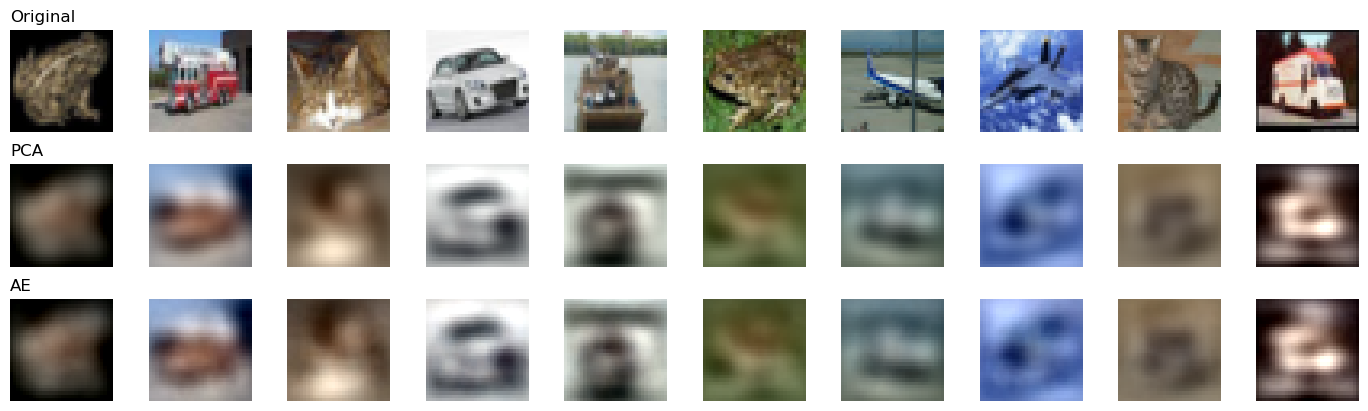

In [25]:
def show_recons(ae_model, pca_model, X_test_np, n=10):
    idx = np.random.choice(len(X_test_np), size=n, replace=False)
    X = torch.tensor(X_test_np[idx]).float().view(n, -1).to(device)
    ae_model.eval()
    with torch.no_grad():
        X_ae = ae_model(X).cpu().numpy()
    X_np = X.cpu().numpy()
    X_pca = pca_model.inverse_transform(pca_model.transform(X_np))
    fig, axes = plt.subplots(3, n, figsize=(1.4*n, 4.2))
    for i in range(n):
        axes[0, i].imshow(X_np[i].reshape(32, 32, 3), cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(X_pca[i].reshape(32, 32, 3), cmap="gray"); axes[1, i].axis("off")
        axes[2, i].imshow(X_ae[i].reshape(32, 32, 3), cmap="gray"); axes[2, i].axis("off")

    axes[0, 0].set_title("Original", fontsize=12, loc='left')
    axes[1, 0].set_title("PCA", fontsize=12, loc='left')
    axes[2, 0].set_title("AE", fontsize=12, loc='left')
    plt.tight_layout()
    plt.show()
    
show_recons(linear_ae, pca, X_test_np, n=10)

# Non Linear AE

In [36]:
nonlinear_ae = SimpleNonLinearAE(input_dim=input_dim, latent_dim=latent_dim, activation=nn.SELU()).to(device)
train_ae_mse(nonlinear_ae, train_dl, test_dl, epochs=30, lr=1e-3)

epoch 01 | AE test MSE: 0.027946
epoch 02 | AE test MSE: 0.019081
epoch 03 | AE test MSE: 0.015636
epoch 04 | AE test MSE: 0.013590
epoch 05 | AE test MSE: 0.013961
epoch 06 | AE test MSE: 0.013079
epoch 07 | AE test MSE: 0.013003
epoch 08 | AE test MSE: 0.013007
epoch 09 | AE test MSE: 0.012964
epoch 10 | AE test MSE: 0.012895
epoch 11 | AE test MSE: 0.013177
epoch 12 | AE test MSE: 0.012813
epoch 13 | AE test MSE: 0.012769
epoch 14 | AE test MSE: 0.013199
epoch 15 | AE test MSE: 0.013333
epoch 16 | AE test MSE: 0.012691
epoch 17 | AE test MSE: 0.012816
epoch 18 | AE test MSE: 0.012768
epoch 19 | AE test MSE: 0.012820
epoch 20 | AE test MSE: 0.012656
epoch 21 | AE test MSE: 0.013002
epoch 22 | AE test MSE: 0.012789
epoch 23 | AE test MSE: 0.012632
epoch 24 | AE test MSE: 0.012664
epoch 25 | AE test MSE: 0.012763
epoch 26 | AE test MSE: 0.012636
epoch 27 | AE test MSE: 0.012594
epoch 28 | AE test MSE: 0.013303
epoch 29 | AE test MSE: 0.012913
epoch 30 | AE test MSE: 0.012653


0.012653253507614136

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10693692602049043..1.024132899893114].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10664141..1.068415].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01669077886940401..1.1150577809612416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.015331365..1.0983706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09415074327000544..0.8563269896695738].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08000052..0.82194465].
Clipping input data to the valid range for imshow with RGB data ([0..1]

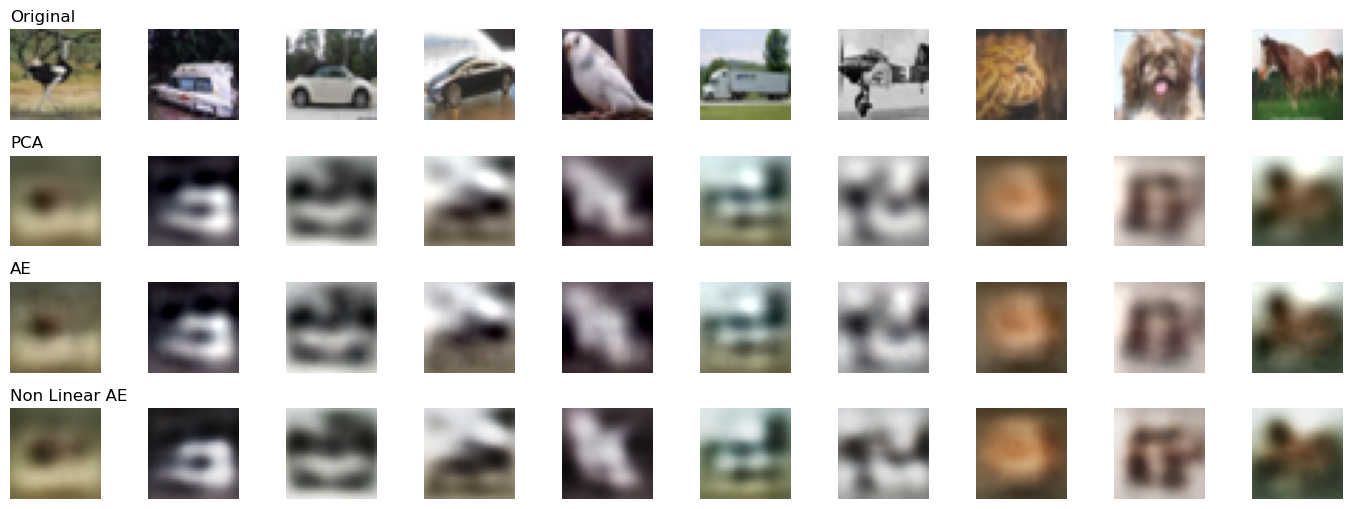

In [37]:
def show_recons(ae_model, nonlinear_ae_model, pca_model, X_test_np, n=10):
    idx = np.random.choice(len(X_test_np), size=n, replace=False)
    X = torch.tensor(X_test_np[idx]).float().view(n, -1).to(device)
    ae_model.eval()
    with torch.no_grad():
        X_ae = ae_model(X).cpu().numpy()
        
    nonlinear_ae_model.eval()
    with torch.no_grad():
        X_non_ae = nonlinear_ae_model(X).cpu().numpy()
    
    X_np = X.cpu().numpy()
    X_pca = pca_model.inverse_transform(pca_model.transform(X_np))
    fig, axes = plt.subplots(4, n, figsize=(1.4*n, 5.2))
    for i in range(n):
        axes[0, i].imshow(X_np[i].reshape(32, 32, 3), cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(X_pca[i].reshape(32, 32, 3), cmap="gray"); axes[1, i].axis("off")
        axes[2, i].imshow(X_ae[i].reshape(32, 32, 3), cmap="gray"); axes[2, i].axis("off")
        axes[3, i].imshow(X_non_ae[i].reshape(32, 32, 3), cmap="gray"); axes[3, i].axis("off")

    axes[0, 0].set_title("Original", fontsize=12, loc='left')
    axes[1, 0].set_title("PCA", fontsize=12, loc='left')
    axes[2, 0].set_title("AE", fontsize=12, loc='left')
    axes[3, 0].set_title("Non Linear AE", fontsize=12, loc='left')
    plt.tight_layout()
    plt.show()
    
show_recons(linear_ae, nonlinear_ae, pca, X_test_np, n=10)

# Latent Dimension vs Overfitting

keep increasing Latent Dimension tell see when it stop and start overfit

In [41]:
latent_dims = [16, 32, 64, 128, 256]
losses = []
for latent_dim in latent_dims:
    stacked_ae = StackedAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
    loss = train_ae_mse(stacked_ae, train_dl, test_dl, epochs=10)
    losses.append(loss)

epoch 01 | AE test MSE: 0.020471
epoch 02 | AE test MSE: 0.019491
epoch 03 | AE test MSE: 0.019006
epoch 04 | AE test MSE: 0.018819
epoch 05 | AE test MSE: 0.018814
epoch 06 | AE test MSE: 0.018727
epoch 07 | AE test MSE: 0.018856
epoch 08 | AE test MSE: 0.018852
epoch 09 | AE test MSE: 0.018865
epoch 10 | AE test MSE: 0.018719
epoch 01 | AE test MSE: 0.018371
epoch 02 | AE test MSE: 0.016026
epoch 03 | AE test MSE: 0.014708
epoch 04 | AE test MSE: 0.014040
epoch 05 | AE test MSE: 0.013745
epoch 06 | AE test MSE: 0.013897
epoch 07 | AE test MSE: 0.013584
epoch 08 | AE test MSE: 0.013560
epoch 09 | AE test MSE: 0.013600
epoch 10 | AE test MSE: 0.013648
epoch 01 | AE test MSE: 0.017160
epoch 02 | AE test MSE: 0.014546
epoch 03 | AE test MSE: 0.013250
epoch 04 | AE test MSE: 0.012712
epoch 05 | AE test MSE: 0.012069
epoch 06 | AE test MSE: 0.011689
epoch 07 | AE test MSE: 0.011412
epoch 08 | AE test MSE: 0.011237
epoch 09 | AE test MSE: 0.011047
epoch 10 | AE test MSE: 0.010815
epoch 01 |

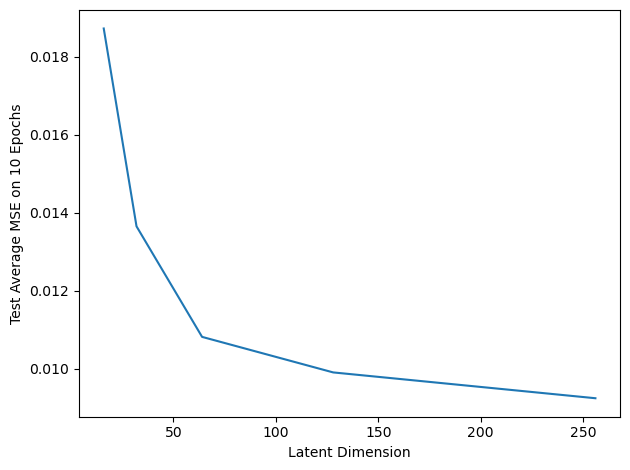

In [42]:
plt.plot(latent_dims, losses)
plt.xlabel("Latent Dimension")
plt.ylabel("Test Average MSE on 10 Epochs")

plt.tight_layout()
plt.show()

In [43]:
32*32*3

3072

# Let's Try Larger latent dimension

In [44]:
latent_dim = 256

linear_ae = SimpleLinearAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
train_ae_mse(linear_ae, train_dl, test_dl, epochs=30, lr=1e-3)


nonlinear_ae = SimpleNonLinearAE(input_dim=input_dim, latent_dim=latent_dim, activation=nn.SELU()).to(device)
train_ae_mse(nonlinear_ae, train_dl, test_dl, epochs=30, lr=1e-3)

stacked_ae = StackedAE(input_dim=input_dim, latent_dim=latent_dim).to(device)
train_ae_mse(stacked_ae, train_dl, test_dl, epochs=30, lr=1e-3)

epoch 01 | AE test MSE: 0.016852
epoch 02 | AE test MSE: 0.011255
epoch 03 | AE test MSE: 0.027017
epoch 04 | AE test MSE: 0.007312
epoch 05 | AE test MSE: 0.006230
epoch 06 | AE test MSE: 0.005484
epoch 07 | AE test MSE: 0.006158
epoch 08 | AE test MSE: 0.006469
epoch 09 | AE test MSE: 0.004186
epoch 10 | AE test MSE: 0.003898
epoch 11 | AE test MSE: 0.003800
epoch 12 | AE test MSE: 0.008866
epoch 13 | AE test MSE: 0.004661
epoch 14 | AE test MSE: 0.004166
epoch 15 | AE test MSE: 0.004140
epoch 16 | AE test MSE: 0.003685
epoch 17 | AE test MSE: 0.003572
epoch 18 | AE test MSE: 0.003489
epoch 19 | AE test MSE: 0.003458
epoch 20 | AE test MSE: 0.003355
epoch 21 | AE test MSE: 0.003289
epoch 22 | AE test MSE: 0.003244
epoch 23 | AE test MSE: 0.003344
epoch 24 | AE test MSE: 0.003157
epoch 25 | AE test MSE: 0.003891
epoch 26 | AE test MSE: 0.003132
epoch 27 | AE test MSE: 0.003057
epoch 28 | AE test MSE: 0.003209
epoch 29 | AE test MSE: 0.003300
epoch 30 | AE test MSE: 0.003018
epoch 01 |

0.008043330213427544

In [46]:
from sklearn.decomposition import PCA


pca = PCA(n_components=latent_dim, random_state=0)

Z_train = pca.fit_transform(X_train_np)
X_test_pca_recon = pca.inverse_transform(pca.transform(X_test_np))

pca_test_mse = np.mean((X_test_pca_recon - X_test_np) ** 2)
print(f"PCA test MSE: {pca_test_mse:.6f}")

PCA test MSE: 0.002620


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.008933361632571357..1.0693269800158802].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.009731771..1.0385743].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07164223386543223..1.0336904216153178].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.055867773..1.0405747].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.015042051280331814..1.0979630465916177].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.02635276..1.1061962].
Clipping input data to the valid range for imshow with RGB data ([0..

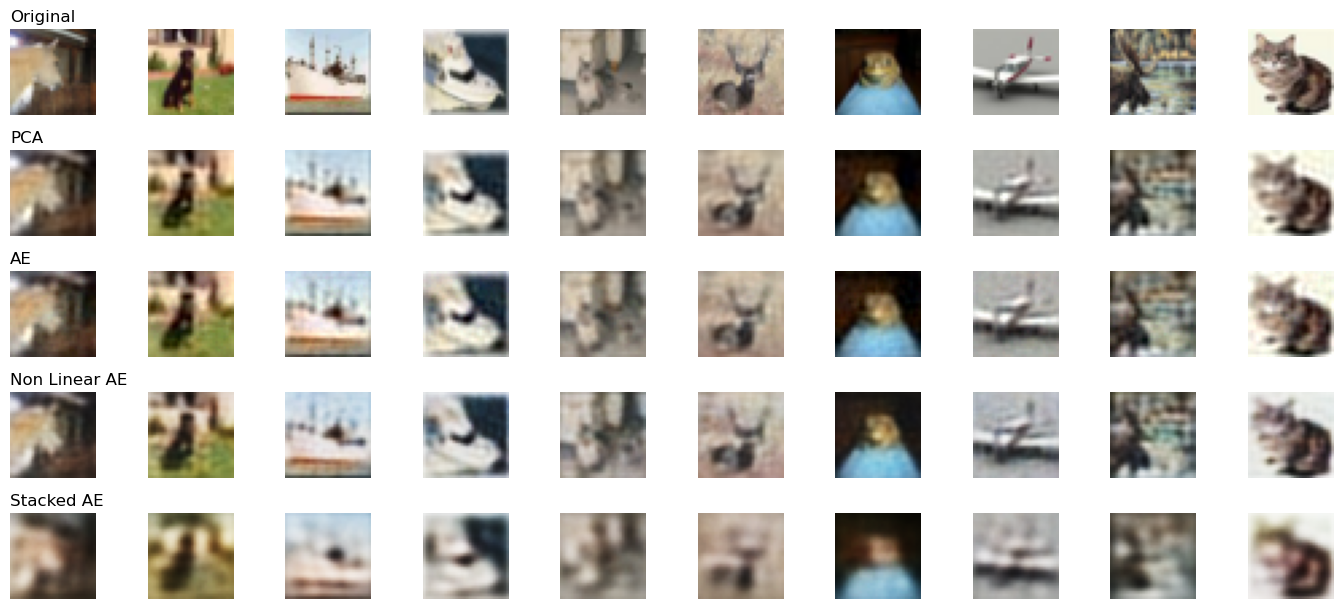

In [47]:
def show_recons(ae_model, nonlinear_ae_model, stacked_ae_model, pca_model, X_test_np, n=10):
    idx = np.random.choice(len(X_test_np), size=n, replace=False)
    X = torch.tensor(X_test_np[idx]).float().view(n, -1).to(device)
    ae_model.eval()
    with torch.no_grad():
        X_ae = ae_model(X).cpu().numpy()
        
    nonlinear_ae_model.eval()
    with torch.no_grad():
        X_non_ae = nonlinear_ae_model(X).cpu().numpy()
        
    stacked_ae_model.eval()
    with torch.no_grad():
        X_stacked_ae = stacked_ae_model(X).cpu().numpy()
    
    X_np = X.cpu().numpy()
    X_pca = pca_model.inverse_transform(pca_model.transform(X_np))
    fig, axes = plt.subplots(5, n, figsize=(1.4*n, 6.2))
    for i in range(n):
        axes[0, i].imshow(X_np[i].reshape(32, 32, 3), cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(X_pca[i].reshape(32, 32, 3), cmap="gray"); axes[1, i].axis("off")
        axes[2, i].imshow(X_ae[i].reshape(32, 32, 3), cmap="gray"); axes[2, i].axis("off")
        axes[3, i].imshow(X_non_ae[i].reshape(32, 32, 3), cmap="gray"); axes[3, i].axis("off")
        axes[4, i].imshow(X_stacked_ae[i].reshape(32, 32, 3), cmap="gray"); axes[4, i].axis("off")

    axes[0, 0].set_title("Original", fontsize=12, loc='left')
    axes[1, 0].set_title("PCA", fontsize=12, loc='left')
    axes[2, 0].set_title("AE", fontsize=12, loc='left')
    axes[3, 0].set_title("Non Linear AE", fontsize=12, loc='left')
    axes[4, 0].set_title("Stacked AE", fontsize=12, loc='left')
    plt.tight_layout()
    plt.show()
    
show_recons(linear_ae, nonlinear_ae, stacked_ae, pca, X_test_np, n=10)